In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence, plot_objective
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.rcParams['axes.unicode_minus'] = False  
plt.style.use('seaborn-v0_8')


plt.rcParams.update({
    'font.serif': 'Times New Roman',  
    'axes.unicode_minus': False,
    'font.size': 12,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'mathtext.fontset': 'stix' 
})
sns.set_palette("husl")
seed = 42
np.random.seed(seed)

data = pd.read_excel(r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN.xlsx', sheet_name='Sheet1')
high_freq = data.iloc[:, 1].values  # Use the second column as the high-frequency component

              Method    RMSE     MAE  SNR(dB)  NRR(dB)  Spectral_Correlation  \
0  Gaussian\n Filter  0.2093  0.1659  11.7167  -1.3546                0.9858   
1     Savitzky-Golay  0.2530  0.2022  10.1080  -1.2703                0.9862   
2            Wavelet  0.2767  0.2205   9.0954  -1.9039                0.9784   
3   Moving\n Average  0.2878  0.2284   8.5357  -2.5883                0.9833   
4          EMD-based  0.2711  0.2207   9.5085  -1.4240                0.9790   
5      CEEMDAN-based  0.2704  0.2199   9.5175  -1.4439                0.9791   

   Transient_Response  
0              0.7995  
1              0.4787  
2              0.4437  
3              0.3876  
4              0.4615  
5              0.4619  


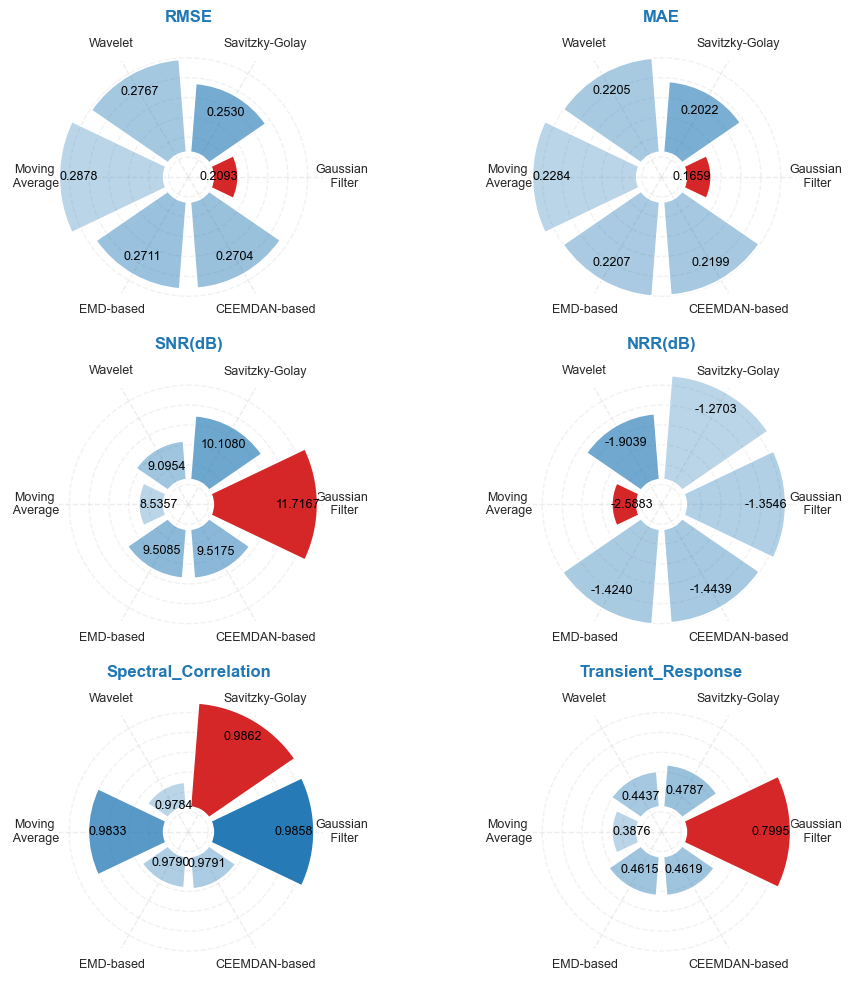

In [6]:
from matplotlib import colors
from scipy.signal import savgol_filter
import pywt
from PyEMD import EMD, CEEMDAN

def calculate_snr(original, filtered):
    noise = original - filtered
    signal_power = np.sum(filtered**2)
    noise_power = np.sum(noise**2)
    if noise_power < 1e-10:
        return 100.0
    return 10 * np.log10(signal_power / noise_power)
def mean_absolute_error(original, filtered):
    return np.mean(np.abs(original - filtered))
def mean_squared_error(original, filtered):
    return np.mean((original - filtered)**2)
def moving_average(x, window=51):
    if window < 1:
        window = 1
    window = min(window, len(x))
    return np.convolve(x, np.ones(window)/window, mode='same')
def calculate_nrr(original, filtered, smooth_window=51):
    signal_before_est = moving_average(original, window=smooth_window)
    signal_after_est  = moving_average(filtered, window=smooth_window)
    noise_before = original - signal_before_est
    noise_after  = filtered - signal_after_est
    noise_before_power = np.mean(noise_before**2)
    noise_after_power  = np.mean(noise_after**2)
    if noise_before_power < 1e-10:
        return np.inf, np.inf
    nrr = noise_after_power / noise_before_power
    nrr_db = 10 * np.log10(nrr)
    return nrr, nrr_db
def spectral_correlation(original, filtered):
    spec_orig = np.abs(np.fft.rfft(original))
    spec_filt = np.abs(np.fft.rfft(filtered))
    corr_matrix = np.corrcoef(spec_orig, spec_filt)
    return corr_matrix[0, 1]
def transient_response(original, filtered):
    grad_orig = np.gradient(original)
    grad_filt = np.gradient(filtered)
    corr_matrix = np.corrcoef(grad_orig, grad_filt)
    return corr_matrix[0, 1]
def wavelet_denoising_optimized(signal, wavelet='db4', level=None, method='bayes', threshold_type='soft'):
    if level is None:
        level = pywt.dwt_max_level(len(signal), pywt.Wavelet(wavelet).dec_len)
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    coeffs_thresh = [coeffs[0]] 
    for c in coeffs[1:]:
        if method == 'visu':
            uthresh = sigma * np.sqrt(2*np.log(len(signal)))
        elif method == 'bayes':
            var_c = np.var(c)
            var_noise = sigma**2
            uthresh = var_noise / np.sqrt(max(var_c - var_noise, 1e-10))
        else:
            uthresh = sigma * np.sqrt(2*np.log(len(signal)))
        c_thresh = pywt.threshold(c, uthresh, threshold_type)
        coeffs_thresh.append(c_thresh)
    return pywt.waverec(coeffs_thresh, wavelet)
def moving_average_filter(signal, window=5):
    return np.convolve(signal, np.ones(window)/window, mode='same')
def emd_filter(signal, imf_keep='low'):
    emd = EMD()
    imfs = emd(signal)
    if imfs.shape[0] == 0:
        return signal
    if imf_keep == 'low':
        keep_imfs = imfs[-6:]  
    elif imf_keep == 'midlow':
        keep_imfs = imfs[-5:]
    else:
        keep_imfs = imfs
    return np.sum(keep_imfs, axis=0)
def ceemdan_filter(signal, imf_keep='low'):
    ceemdan = CEEMDAN()
    imfs = ceemdan(signal)
    if imfs.shape[0] == 0:
        return signal
    if imf_keep == 'low':
        keep_imfs = imfs[-6:]  
    elif imf_keep == 'midlow':
        keep_imfs = imfs[-5:]
    else:
        keep_imfs = imfs
    return np.sum(keep_imfs, axis=0)
def compare_filters(original):
    results = []
    methods = {
        'Gaussian\n Filter': gaussian_filter1d(original, sigma=1.0, mode='nearest'),
        'Savitzky-Golay': savgol_filter(original, window_length=9, polyorder=3),
        'Wavelet': wavelet_denoising_optimized(original, wavelet='db4', level=None),
        'Moving\n Average': moving_average_filter(original, window=9),
        'EMD-based': emd_filter(original, imf_keep='low'),
        'CEEMDAN-based': ceemdan_filter(original, imf_keep='low')
    }
    for name, filt in methods.items():
        rmse = np.sqrt(mean_squared_error(original, filt))
        mae = mean_absolute_error(original, filt)
        snr = calculate_snr(original, filt)
        nrr_lin, nrr_db = calculate_nrr(original, filt) 
        spec_corr = spectral_correlation(original, filt)
        trans_corr = transient_response(original, filt)
        results.append({
            'Method': name,
            'RMSE': rmse,
            'MAE': mae,
            'SNR(dB)': snr,
            'NRR(dB)': nrr_db,
            'Spectral_Correlation': spec_corr,
            'Transient_Response': trans_corr
        })
    return pd.DataFrame(results)
def plot_enhanced_filter_comparison(results_df):
    metrics = ['RMSE', 'MAE', 'SNR(dB)', 'NRR(dB)',
               'Spectral_Correlation', 'Transient_Response']
    methods = results_df['Method'].values
    num_methods = len(methods)
    fig, axes = plt.subplots(3, 2, subplot_kw=dict(polar=True), figsize=(10, 10))
    axes = axes.flatten()
    hole_radius = 0.25
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = results_df[metric].values
        theta = np.linspace(0, 2 * np.pi, num_methods, endpoint=False)
        width = 2 * np.pi / num_methods
        norm_vals = (values - np.min(values)) / (np.max(values) - np.min(values) + 1e-10)
        if metric in ['RMSE', 'MAE', 'NRR(dB)']:
            best_idx = np.argmin(values)
        else:
            best_idx = np.argmax(values)

        for i, (angle, val, norm_val) in enumerate(zip(theta, values, norm_vals)):
            if metric in ['RMSE', 'MAE', 'NRR(dB)']:
                if i == best_idx:
                    color = colors.to_rgba('tab:red', 1.0)
                else:
                    blue_strength = 1.0 - 0.7 * norm_val  
                    alpha = blue_strength  
                    color = colors.to_rgba('tab:blue', alpha)
            else:
                if i == best_idx:
                    color = colors.to_rgba('tab:red', 1.0)
                else:
                    blue_strength = 0.3 + 0.7 * norm_val
                    alpha = blue_strength
                    color = colors.to_rgba('tab:blue', alpha)

            bar_height = hole_radius + norm_val * 0.8
            ax.bar(angle, bar_height, width=width * 0.85,
                   bottom=hole_radius, color=color, edgecolor='white', linewidth=1.2)
            ax.text(angle, bar_height + 0.05, f"{val:.4f}",
                    ha='center', va='center', fontsize=9, color='black')

        ax.set_xticks(theta)
        xticklabels = [f"{m}" if m == 'Gaussian\n Filter' else m for m in methods]
        ax.set_xticklabels(xticklabels, fontsize=9)
        ax.spines['polar'].set_visible(False)
        ax.xaxis.grid(True, color='lightgrey', linestyle='--', alpha=0.4)
        ax.yaxis.grid(True, color='lightgrey', linestyle='--', alpha=0.3)
        ax.set_title(metric, fontsize=12, fontweight='bold', pad=15, color='tab:blue')
        ax.set_yticklabels([])

    plt.tight_layout()
    plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig5.pdf', format='pdf', dpi=300)
    plt.show()

if __name__ == "__main__":
    np.random.seed(0)
    t = np.linspace(0, 5, 1000)
    clean = np.sin(2*np.pi*2*t) + 0.5*np.sin(2*np.pi*8*t)
    noise = 0.3 * np.random.randn(len(t))
    noisy_signal = clean + noise
    results_df = compare_filters(noisy_signal)
    print(results_df.round(4))

    plot_enhanced_filter_comparison(results_df)



Gaussian filter sensitivity analysis (first 10 rows):
    Sigma     RMSE      MAE     SNR  NRR_Linear  NRR_dB  Spectral_Correlation  \
0  1.0000  20.7579  14.2923  3.3198      0.4378 -3.5874                0.9277   
1  1.0408  21.5846  14.9021  2.7588      0.4160 -3.8092                0.9213   
2  1.0816  22.3893  15.4941  2.2162      0.3950 -4.0338                0.9147   
3  1.1224  23.1730  16.0680  1.6900      0.3749 -4.2612                0.9077   
4  1.1633  23.9376  16.6305  1.1772      0.3555 -4.4921                0.9005   
5  1.2041  24.6822  17.1781  0.6783      0.3369 -4.7249                0.8931   
6  1.2449  25.4076  17.7093  0.1914      0.3191 -4.9602                0.8854   
7  1.2857  26.1143  18.2268 -0.2843      0.3022 -5.1976                0.8774   
8  1.3265  26.8023  18.7276 -0.7497      0.2859 -5.4371                0.8693   
9  1.3673  27.4720  19.2121 -1.2053      0.2705 -5.6784                0.8609   

   Transient_Response  
0              0.9327  
1    

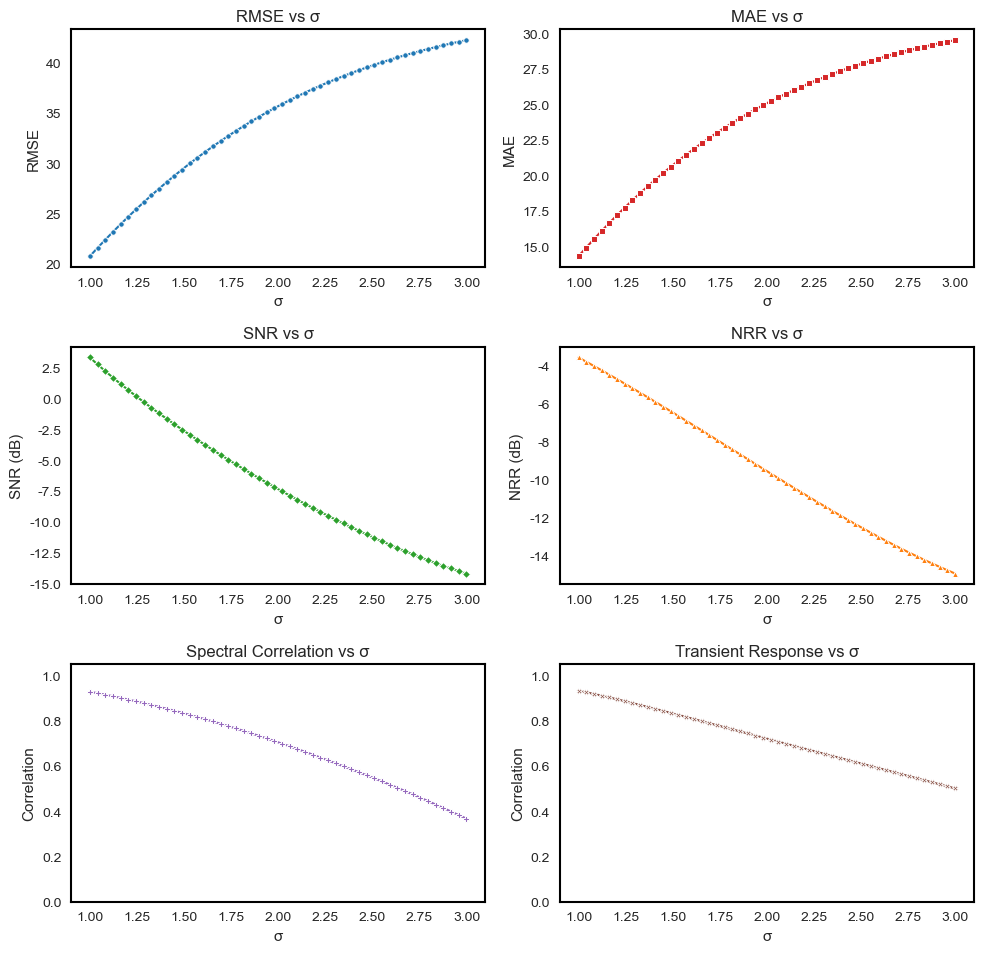

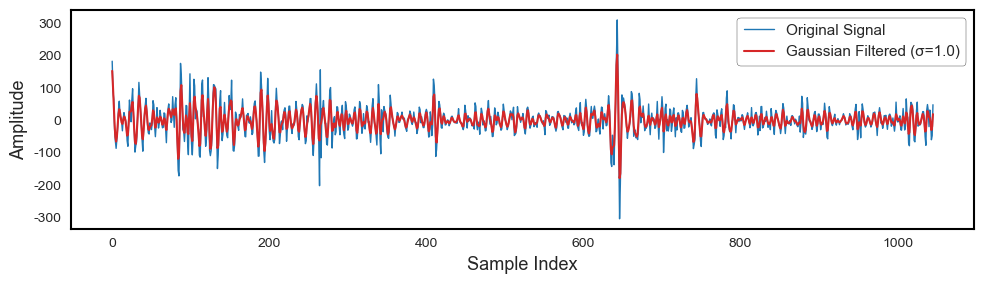

In [5]:
# ================== SNR  ==================
def calculate_snr(original, filtered):
    """
    Compute global Signal-to-Noise Ratio (SNR) in dB
    """
    noise = original - filtered
    signal_power = np.sum(filtered**2)
    noise_power = np.sum(noise**2)
    if noise_power < 1e-10:
        return 100.0  
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

# ================== Mean Absolute Error (MAE) ==================
def mean_absolute_error(original, filtered):
    """
    Compute Mean Absolute Error (MAE)
    """
    return np.mean(np.abs(original - filtered))

# ================== Noise Reduction Ratio (NRR) ==================
def calculate_nrr(original, filtered):
    """
    Compute Noise Reduction Ratio (NRR)
    Returns: (linear value, dB value)
    """
    noise_before = original - np.mean(original)
    noise_after = filtered - np.mean(filtered)
    noise_before_power = np.mean(noise_before**2)
    noise_after_power = np.mean(noise_after**2)
    if noise_before_power < 1e-10:
        return np.inf, np.inf
    nrr = noise_after_power / noise_before_power
    nrr_db = 10 * np.log10(nrr)
    return nrr, nrr_db

# ================== Spectral Correlation ==================
def spectral_correlation(original, filtered):
    """
    Compute spectral magnitude correlation coefficient
    """
    spec_orig = np.abs(np.fft.rfft(original))
    spec_filt = np.abs(np.fft.rfft(filtered))
    corr_matrix = np.corrcoef(spec_orig, spec_filt)
    return corr_matrix[0, 1]

# ================== Transient Response (Gradient Correlation) ==================
def transient_response(original, filtered):
    """
    Compute correlation coefficient of first-order gradients
    """
    grad_orig = np.gradient(original)
    grad_filt = np.gradient(filtered)
    corr_matrix = np.corrcoef(grad_orig, grad_filt)
    return corr_matrix[0, 1]

# ================== Sensitivity Analysis Main Function ==================
def sensitivity_analysis(original, sigma_values):
    """Analyze Gaussian filter sensitivity with six key metrics"""
    results = []
    for sigma in sigma_values:
        filtered = gaussian_filter1d(original, sigma=sigma, mode='nearest')

        rmse = np.sqrt(mean_squared_error(original, filtered))
        mae = mean_absolute_error(original, filtered)
        snr = calculate_snr(original, filtered)
        nrr_linear, nrr_db = calculate_nrr(original, filtered)
        spec_corr = spectral_correlation(original, filtered)
        transient_corr = transient_response(original, filtered)
        results.append({
            'Sigma': sigma,
            'RMSE': rmse,
            'MAE': mae,
            'SNR': snr,
            'NRR_Linear': nrr_linear,
            'NRR_dB': nrr_db,
            'Spectral_Correlation': spec_corr,
            'Transient_Response': transient_corr
        })
    return pd.DataFrame(results)

def plot_sensitivity_results(results):
    """3x2 subplot visualization of six key metrics as a function of sigma"""
    fig, axes = plt.subplots(3, 2, figsize=(10, 10))

    sns.lineplot(data=results, x='Sigma', y='RMSE', ax=axes[0, 0], marker='o', markersize=4, color='tab:blue', linewidth=1.5)
    axes[0, 0].set_title('RMSE vs σ')
    axes[0, 0].set_xlabel('σ'); axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].grid(True, alpha=0.7)
    
    sns.lineplot(data=results, x='Sigma', y='MAE', ax=axes[0, 1], marker='s', markersize=4, color='tab:red', linewidth=1.5)
    axes[0, 1].set_title('MAE vs σ')
    axes[0, 1].set_xlabel('σ'); axes[0, 1].set_ylabel('MAE')
    axes[0, 1].grid(True, alpha=0.7)
    
    sns.lineplot(data=results, x='Sigma', y='SNR', ax=axes[1, 0], marker='D', markersize=4, color='tab:green', linewidth=1.5)
    axes[1, 0].set_title('SNR vs σ')
    axes[1, 0].set_xlabel('σ'); axes[1, 0].set_ylabel('SNR (dB)')
    axes[1, 0].grid(True, alpha=0.7)
    
    sns.lineplot(data=results, x='Sigma', y='NRR_dB', ax=axes[1, 1], marker='^', markersize=4, color='tab:orange', linewidth=1.5)
    axes[1, 1].set_title('NRR vs σ')
    axes[1, 1].set_xlabel('σ'); axes[1, 1].set_ylabel('NRR (dB)')
    axes[1, 1].grid(True, alpha=0.7)
    
    sns.lineplot(data=results, x='Sigma', y='Spectral_Correlation', ax=axes[2, 0], marker='P', markersize=4, color='tab:purple', linewidth=1.5)
    axes[2, 0].set_title('Spectral Correlation vs σ')
    axes[2, 0].set_xlabel('σ'); axes[2, 0].set_ylabel('Correlation')
    axes[2, 0].set_ylim([0.0, 1.05])
    axes[2, 0].grid(True, alpha=0.7)
    
    sns.lineplot(data=results, x='Sigma', y='Transient_Response', ax=axes[2, 1], marker='X', markersize=4, color='tab:brown', linewidth=1.5)
    axes[2, 1].set_title('Transient Response vs σ')
    axes[2, 1].set_xlabel('σ'); axes[2, 1].set_ylabel('Correlation')
    axes[2, 1].set_ylim([0.0, 1.05])
    axes[2, 1].grid(True, alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig5.pdf', format='pdf', dpi=300)
    plt.show()
    plt.close()

if __name__ == "__main__":
    # Set sigma range
    sigma_values = np.linspace(1.0, 3.0, 50)

    # Sensitivity analysis
    results_df = sensitivity_analysis(high_freq, sigma_values)

    # Print first 10 rows
    print("\nGaussian filter sensitivity analysis (first 10 rows):")
    print(results_df.round(4).head(10))
    # Visualize the six metrics
    plot_sensitivity_results(results_df)

    sigma_best = 1.0
    filtered_signal = gaussian_filter1d(high_freq, sigma=sigma_best, mode='nearest')

    plt.figure(figsize=(10, 3))
    plt.plot(high_freq, label='Original Signal', color='tab:blue', linewidth=1.0)
    plt.plot(filtered_signal, label=f'Gaussian Filtered (σ={sigma_best})', color='tab:red', linewidth=1.5)
    plt.xlabel('Sample Index', fontsize=13)
    plt.ylabel('Amplitude', fontsize=13)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='black', fontsize=11)
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()


开始贝叶斯优化...
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 12.6318
Function value obtained: 0.3225
Current minimum: 0.3225
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 12.3702
Function value obtained: 0.3225
Current minimum: 0.3225
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 12.0639
Function value obtained: 0.3225
Current minimum: 0.3225
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 12.6923
Function value obtained: 0.3225
Current minimum: 0.3225
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 13.0263
Function value obtained: 0.3225
Current minimum: 0.3225
Iteration No: 6 sta

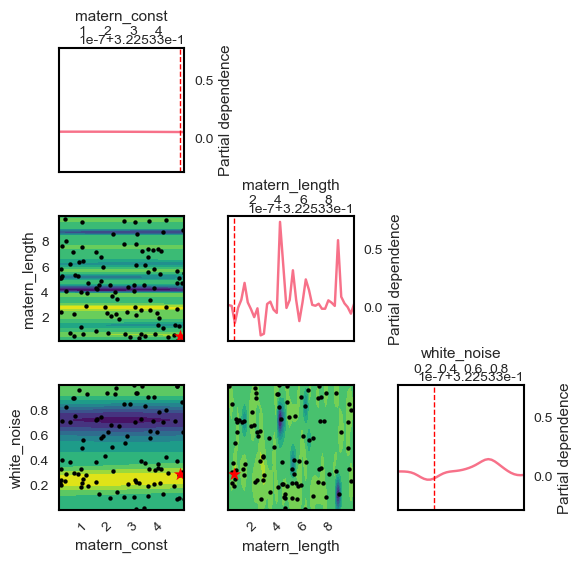

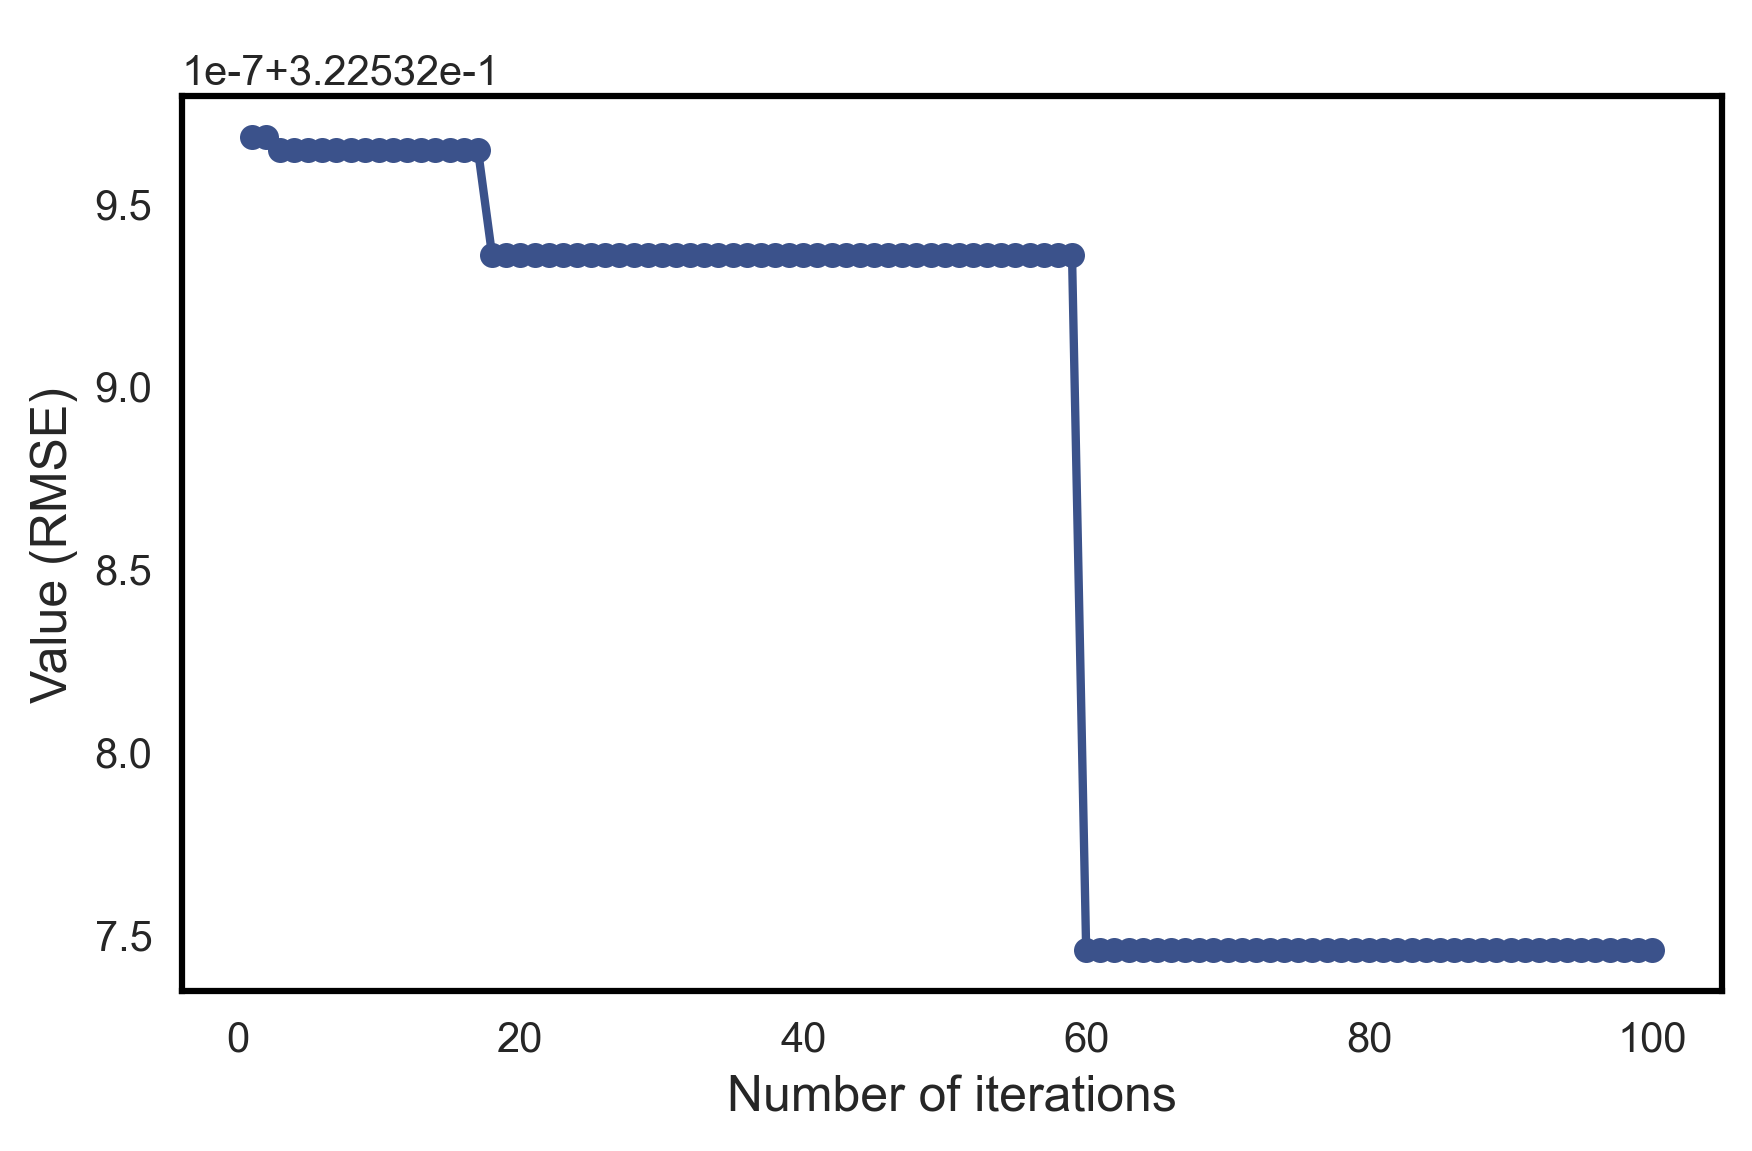


训练最终模型...

模型性能评估:
 Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE  Test MAPE  Train R²  Test R²  Train DR   Test DR
   3.932228    5.59211   2.971166   4.10756 1688.996058 301.282165  0.986321 0.907788 92.424242 88.498403


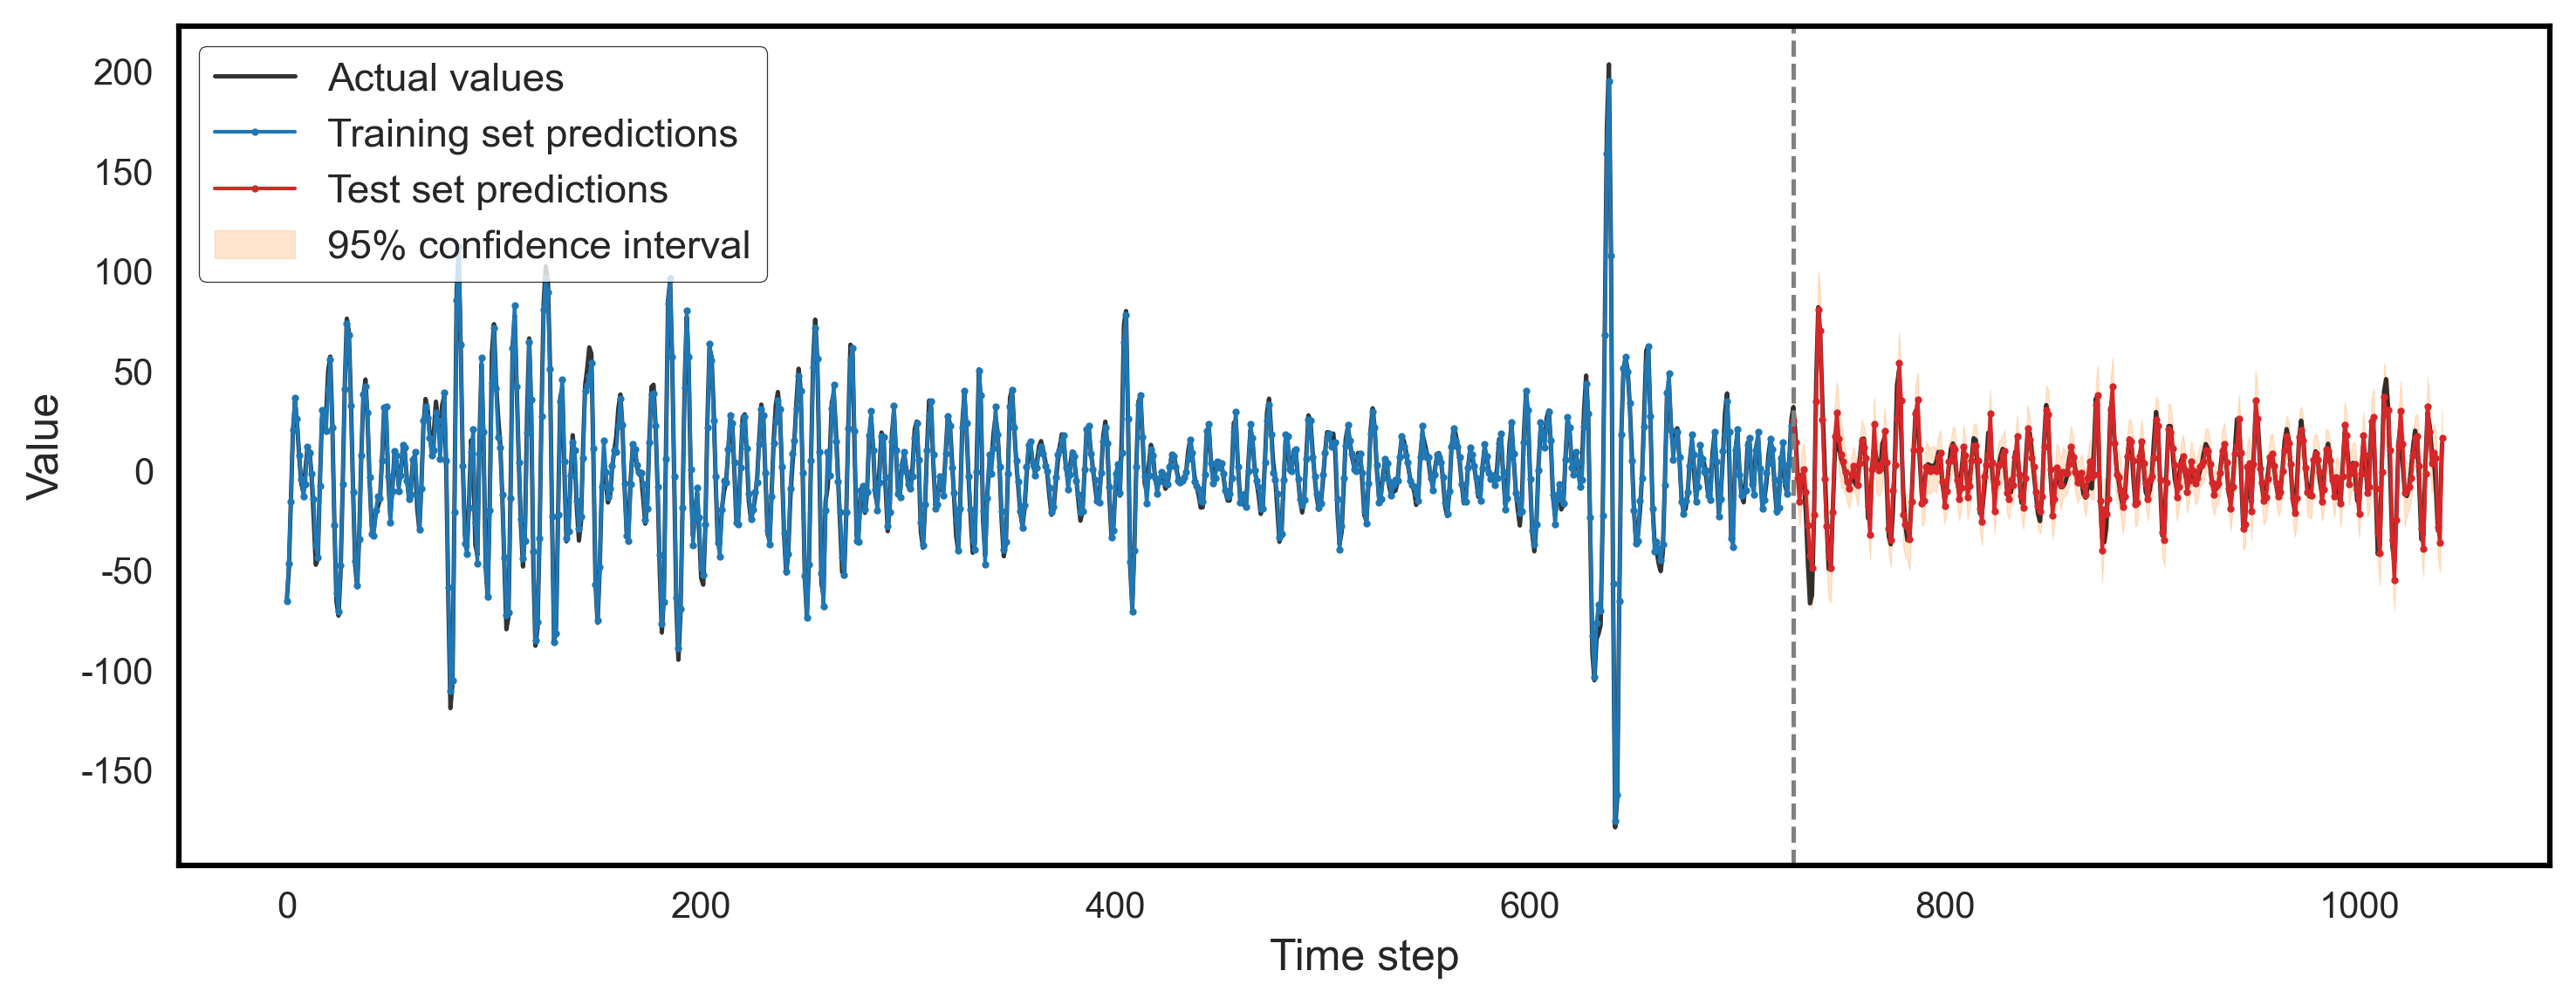


结果已保存至: C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN高频预测结果.xlsx


In [10]:
sigma = 1.0
high_freq_smoothed = gaussian_filter1d(high_freq.flatten(), sigma=sigma).reshape(-1, 1)
n_steps = 5
train_size_original = int(len(high_freq_smoothed) * 0.7)
train_data = high_freq_smoothed[:train_size_original]
test_data = high_freq_smoothed[train_size_original:]
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)
def create_dataset(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps].flatten())
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)
X_train, y_train = create_dataset(train_scaled, n_steps)
test_extended = np.concatenate([train_scaled[-n_steps:], test_scaled])
X_test, y_test = create_dataset(test_extended, n_steps)
dimensions = [
    Real(name='matern_const', low=0.1, high=5),
    Real(name='matern_length', low=0.1, high=10),
    Real(name='white_noise', low=1e-4, high=1)
]
def objective(params):
    matern_amp, matern_length, white_noise = params
    kernel = ConstantKernel(matern_amp) * Matern(length_scale=matern_length, nu=0.5) + \
             WhiteKernel(noise_level=white_noise)
    tscv = TimeSeriesSplit(n_splits=3)
    splits = list(tscv.split(X_train))
    rmse_scores = []
    for train_idx, val_idx in splits:
        gpr = GaussianProcessRegressor(
            kernel=kernel,
            alpha=0,
            n_restarts_optimizer=3,
            random_state=seed
        )
        gpr.fit(X_train[train_idx], y_train[train_idx])
        y_pred = gpr.predict(X_train[val_idx])
        rmse = np.sqrt(mean_squared_error(y_train[val_idx], y_pred))
        rmse_scores.append(rmse)
    return np.mean(rmse_scores)
result = gp_minimize(
    objective,
    dimensions,
    n_calls=100,
    n_random_starts=20,
    random_state=seed,
    verbose=True
)
ax_array = plot_objective(result, size=2, minimum='expected_minimum')
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig8.pdf', format='pdf', dpi=300)
best_params = result.x
best_matern_amp, best_matern_length, best_white_noise = best_params
print(f"最优参数: Matern(const={best_matern_amp:.3f}, ls={best_matern_length:.3f}), WhiteNoise={best_white_noise:.4f}")
fig, ax = plt.subplots(figsize=(6, 4),dpi=300)
plot_convergence(result, ax=ax)
ax.set_title(' ', fontsize=14)
ax.set_xlabel('Number of iterations', fontsize=12)
ax.set_ylabel('Value (RMSE)', fontsize=12)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig7.pdf', format='pdf', dpi=300)
plt.show()
best_kernel = ConstantKernel(best_matern_amp) * Matern(length_scale=best_matern_length, nu=0.5) + \
              WhiteKernel(noise_level=best_white_noise)
gpr = GaussianProcessRegressor(
    kernel=best_kernel,
    alpha=0.05,
    n_restarts_optimizer=10,
    random_state=seed
)
gpr.fit(X_train, y_train)
def predict_and_inverse(model, X):
    y_pred, y_std = model.predict(X, return_std=True)
    y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    return y_pred, y_std
train_pred, train_std = predict_and_inverse(gpr, X_train)
test_pred, test_std = predict_and_inverse(gpr, X_test)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
def safe_mape(y_true, y_pred):
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)) * 100)
def directional_accuracy(y_true, y_pred):
    true_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    correct = (true_direction == pred_direction)
    dr = np.mean(correct) * 100
    return dr
metrics = [
    ('RMSE', lambda y_t, y_p: np.sqrt(mean_squared_error(y_t, y_p))),
    ('MAE', mean_absolute_error),
    ('MAPE', safe_mape),
    ('R²', r2_score),
    ('DR', directional_accuracy)
]
results = {}
for name, metric in metrics:
    train_value = metric(y_train_inv, train_pred)
    test_value = metric(y_test_inv, test_pred)
    results[f'Train {name}'] = train_value
    results[f'Test {name}'] = test_value
results_df = pd.DataFrame([results])
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4),dpi=300)
full_pred = np.concatenate([train_pred, test_pred])
full_actual = np.concatenate([y_train_inv, y_test_inv])
time_index = np.arange(len(full_actual))
ax.plot(time_index, full_actual, color='black', lw=1.2, label='Actual values', alpha=0.8)
ax.plot(time_index[:len(train_pred)], train_pred, 
         color='tab:blue', marker='o', markersize=2, lw=1.0, label='Training set predictions')
ax.plot(time_index[len(train_pred):], test_pred, 
         color='tab:red', marker='o', markersize=2, lw=1.0, label='Test set predictions')
ax.fill_between(time_index[len(train_pred):],
                 test_pred - 1.96*test_std*scaler.scale_[0],
                 test_pred + 1.96*test_std*scaler.scale_[0],
                 color='#ff7f0e', alpha=0.2, label='95% confidence interval')
ax.axvline(x=len(train_pred), color='gray', ls='--', lw=1.2)
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='black', fontsize=11)
ax.grid(alpha=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Fig9.pdf', format='pdf', dpi=300)
plt.show()

output_path = r'C:\Users\h\Desktop\小论文\BDI1000\BO-滤波-GPR\CEEMDAN高频预测结果.xlsx'
with pd.ExcelWriter(output_path) as writer:
    results_df.to_excel(writer, sheet_name='模型评估', index=False)
    pd.DataFrame({
        '实际值': full_actual,
        '预测值': full_pred,
        '预测标准差': np.concatenate([train_std, test_std]) * scaler.scale_[0]
    }).to_excel(writer, sheet_name='完整预测', index=False)
    pd.DataFrame({
        '训练集预测': np.concatenate([train_pred, np.full(len(test_pred), np.nan)]),
        '测试集预测': np.concatenate([np.full(len(train_pred), np.nan), test_pred])
    }).to_excel(writer, sheet_name='分组预测', index=False)

print("\n结果已保存至:", output_path)